Offset relations and Spearman rho vs Σ_* (excluding: {'NGC4383'})
All galaxies (for color assignment): IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Galaxies used in this analysis: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698

Processing IC3392 ...
  Σ* range (95%): 7.739 to 8.911
  Global Δlog(Σ_SFR) axis limits: ±1.175
  Global Δ[O/H] axis limits: ±0.262
  Spearman rho in each Σ_* bin (3σ clip + trend, per galaxy):
    Bin 01 (7.84): n=450, r=N/A (no trend or too few in 3σ)
    Bin 02 (8.03): n=2240, r=0.433 (p=5.28e-102)
    Bin 03 (8.23): n=5467, r=0.311 (p=3.25e-121)
    Bin 04 (8.42): n=3864, r=0.268 (p=5.05e-63)
    Bin 05 (8.62): n=1435, r=0.238 (p=9.89e-20)
    Bin 06 (8.81): n=705, r=0.097 (p=0.0101)

Processing NGC4064 ...
  Σ* range (95%): 7.180 to 9.130
  Global Δlog(Σ_SFR) axis limits: ±2.070
  Global Δ[O/H] axis limits: ±0.26

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_80471/1263374793.py:458: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


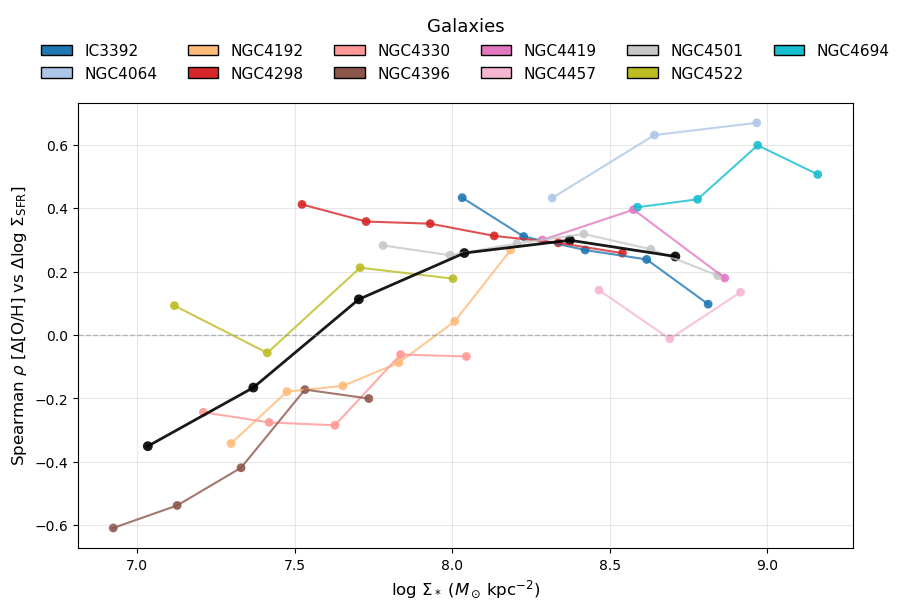

In [1]:
# ------------------------------------------------------------------
# Offset relations: Δ[O/H] vs Δlog Σ_SFR in Σ_* bins
# For all galaxies (excluding NGC4383) and Spearman rho vs Σ_* summary
# Spearman rho uses only points inside 95% contour and only if trend exists
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
# # Prefer widget backend when available; fallback to inline.
# try:
#     get_ipython().run_line_magic('matplotlib', 'widget')
# except Exception:
#     get_ipython().run_line_magic('matplotlib', 'inline')

# ------------------------------------------------------------------
# Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Galaxy list and color map (reserve color for excluded galaxy)
# ------------------------------------------------------------------
all_bin_centers = []  # Σ_* bin centers for which rho is valid (per-galaxy)
all_rho_values = []     # Spearman rho (per-galaxy)
all_galaxy_indices = []

# Also store all spaxels across galaxies to compute a global trend
global_sigM_list = []
global_sigSFR_list = []
global_oh_list = []
global_gal_index_list = []

# Build full galaxy list from available FITS files (including excluded)
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}

# Build galaxy -> color mapping over ALL galaxies (so excluded keeps its color)
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Now define the working sample that EXCLUDES NGC4383 for analysis/plotting
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print(f"Offset relations and Spearman rho vs Σ_* (excluding: {excluded_galaxies})")
print("All galaxies (for color assignment):", ", ".join(galaxies_all))
print("Galaxies used in this analysis:", ", ".join(galaxies))
print("=" * 80)

# ------------------------------------------------------------------
# Loop over galaxies and compute Spearman rho per Σ_* bin (per-galaxy)
# and collect global spaxels for combined trend
# ------------------------------------------------------------------
for gal_index, gal in enumerate(galaxies):
    print(f"\nProcessing {gal} ...")
    try:
        sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)
    except Exception as e:
        print(f"  Skipping {gal}: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    if np.sum(valid_all) == 0:
        print("  No valid pixels.")
        continue

    # Collect into global arrays for combined analysis
    global_sigM_list.append(sigM[valid_all].ravel())
    global_sigSFR_list.append(sigSFR[valid_all].ravel())
    global_oh_list.append(oh_o3n2_map[valid_all].ravel())
    global_gal_index_list.append(np.full(np.sum(valid_all), gal_index, dtype=int))

    # 1. Define 6 Σ_* bins for this galaxy (spanning 95% population)
    n_bins = 6
    sigmaM_min = np.nanpercentile(sigM[valid_all], 2.5)
    sigmaM_max = np.nanpercentile(sigM[valid_all], 97.5)
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    sigmaM_bin_centers = 0.5 * (sigmaM_bin_edges[:-1] + sigmaM_bin_edges[1:])

    # 2. Global symmetric limits for this galaxy (for reference / consistency)
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]

            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            if np.any(np.isfinite(sfr_offset)):
                global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            if np.any(np.isfinite(oh_offset)):
                global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    print(f"  Σ* range (95%): {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
    print(f"  Global Δ[O/H] axis limits: ±{global_max_abs_oh:.3f}")

    # 3. Compute Spearman rho in each Σ_* bin using 3-sigma clipping on unique data (per galaxy)
    print("  Spearman rho in each Σ_* bin (3σ clip + trend, per galaxy):")
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        n_pixels = np.sum(bin_mask)

        if n_pixels <= 0:
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n=0, r=N/A")
            continue

        # Values in this Σ_* bin
        sfr_bin = sigSFR[bin_mask]
        oh_bin = oh_o3n2_map[bin_mask]

        # Offsets within this bin
        sfr_bin_mean = np.mean(sfr_bin)
        oh_bin_mean = np.mean(oh_bin)

        sfr_offset = sfr_bin - sfr_bin_mean
        oh_offset = oh_bin - oh_bin_mean

        valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

        if np.sum(valid_corr) <= 2:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (insufficient valid points)")
            continue

        # ------------------------------------------------------------------
        # Calculate 3-sigma clipping mask on unique valid data
        # ------------------------------------------------------------------
        sigma_clip_mask = np.zeros_like(valid_corr, dtype=bool)
        if np.sum(valid_corr) > 0:
            # Get unique valid data using np.unique
            sfr_data = sfr_offset[valid_corr]
            oh_data = oh_offset[valid_corr]
            
            sfr_unique = np.unique(sfr_data)
            oh_unique = np.unique(oh_data)
            
            # Calculate mean and std on unique values
            x_mean = np.mean(sfr_unique)
            x_std = np.std(sfr_unique)
            y_mean = np.mean(oh_unique)
            y_std = np.std(oh_unique)
            
            # 3-sigma bounds
            x_lower = x_mean - 3 * x_std
            x_upper = x_mean + 3 * x_std
            y_lower = y_mean - 3 * y_std
            y_upper = y_mean + 3 * y_std
            
            # Apply 3-sigma clipping to all data points
            within_3sigma = (sfr_data >= x_lower) & (sfr_data <= x_upper) & \
                            (oh_data >= y_lower) & (oh_data <= y_upper)
            sigma_clip_mask[valid_corr] = within_3sigma

        # ------------------------------------------------------------------
        # Median trend using only points within 3-sigma
        # ------------------------------------------------------------------
        x_trend = sfr_offset[sigma_clip_mask]
        y_trend = oh_offset[sigma_clip_mask]

        centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                bin_width=0.2,
                                                                min_unique=20)

        # Require at least 2 median-trend points for a valid trend
        has_trend = centers.size >= 2

        # ------------------------------------------------------------------
        # Spearman rho: only for points within 3-sigma and only if trend exists
        # ------------------------------------------------------------------
        if has_trend and np.sum(sigma_clip_mask & valid_corr) > 2:
            try:
                spearman_rho, spearman_p = spearmanr(sfr_offset[sigma_clip_mask & valid_corr],
                                                oh_offset[sigma_clip_mask & valid_corr])
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r={spearman_rho:.3f} (p={spearman_p:.3g})")
            except Exception:
                spearman_rho = np.nan
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (error)")
        else:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (no trend or too few in 3σ)")

        # Store only valid rho values
        if np.isfinite(spearman_rho):
            all_bin_centers.append(sigmaM_bin_centers[i])
            all_rho_values.append(spearman_rho)
            all_galaxy_indices.append(gal_index)

# ------------------------------------------------------------------
# Prepare global arrays for combined Spearman vs Σ_* (all galaxies)
# ------------------------------------------------------------------
if global_sigM_list:
    global_sigM = np.concatenate(global_sigM_list)
    global_sigSFR = np.concatenate(global_sigSFR_list)
    global_oh = np.concatenate(global_oh_list)
else:
    global_sigM = np.array([])
    global_sigSFR = np.array([])
    global_oh = np.array([])

# ------------------------------------------------------------------
# Convert collected per-galaxy Spearman rho data to arrays
# ------------------------------------------------------------------
all_bin_centers = np.array(all_bin_centers)
all_rho_values = np.array(all_rho_values)
all_galaxy_indices = np.array(all_galaxy_indices)

print("\n" + "=" * 80)
print("Summary: number of Σ_* bins with valid Spearman rho (per galaxy):", len(all_rho_values))
print("=" * 80)

# ------------------------------------------------------------------
# Compute combined Spearman rho vs Σ_* over all galaxies (same method)
# ------------------------------------------------------------------
global_bin_centers = []
global_rho_values = []

if global_sigM.size > 0:
    # Define 6 Σ_* bins for the combined sample (spanning 95% population)
    n_bins_global = 6
    sigmaM_min_g = np.nanpercentile(global_sigM, 2.5)
    sigmaM_max_g = np.nanpercentile(global_sigM, 97.5)
    sigmaM_edges_g = np.linspace(sigmaM_min_g, sigmaM_max_g, n_bins_global + 1)
    sigmaM_centers_g = 0.5 * (sigmaM_edges_g[:-1] + sigmaM_edges_g[1:])

    print("\nComputing combined Spearman rho in Σ_* bins (all galaxies together)...")
    for i in range(n_bins_global):
        if i == 0:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])
        elif i == n_bins_global - 1:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM <= sigmaM_edges_g[i+1])
        else:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])

        n_pix_g = np.sum(bin_mask_g)
        if n_pix_g <= 0:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n=0, r=N/A")
            continue

        sfr_bin_g = global_sigSFR[bin_mask_g]
        oh_bin_g = global_oh[bin_mask_g]

        sfr_mean_g = np.mean(sfr_bin_g)
        oh_mean_g = np.mean(oh_bin_g)

        sfr_off_g = sfr_bin_g - sfr_mean_g
        oh_off_g = oh_bin_g - oh_mean_g

        valid_corr_g = np.isfinite(sfr_off_g) & np.isfinite(oh_off_g)
        if np.sum(valid_corr_g) <= 2:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (insufficient valid points)")
            continue

        # ------------------------------------------------------------------
        # Calculate 3-sigma clipping mask on unique valid data (global)
        # ------------------------------------------------------------------
        sigma_clip_mask_global = np.zeros_like(valid_corr_g, dtype=bool)
        if np.sum(valid_corr_g) > 0:
            sfr_data_g = sfr_off_g[valid_corr_g]
            oh_data_g = oh_off_g[valid_corr_g]
            
            sfr_unique_g = np.unique(sfr_data_g)
            oh_unique_g = np.unique(oh_data_g)
            
            x_mean_g = np.mean(sfr_unique_g)
            x_std_g = np.std(sfr_unique_g)
            y_mean_g = np.mean(oh_unique_g)
            y_std_g = np.std(oh_unique_g)
            
            x_lower_g = x_mean_g - 3 * x_std_g
            x_upper_g = x_mean_g + 3 * x_std_g
            y_lower_g = y_mean_g - 3 * y_std_g
            y_upper_g = y_mean_g + 3 * y_std_g
            
            within_3sigma_g = (sfr_data_g >= x_lower_g) & (sfr_data_g <= x_upper_g) & \
                              (oh_data_g >= y_lower_g) & (oh_data_g <= y_upper_g)
            sigma_clip_mask_global[valid_corr_g] = within_3sigma_g

        x_trend_g = sfr_off_g[sigma_clip_mask_global]
        y_trend_g = oh_off_g[sigma_clip_mask_global]

        centers_g, medians_g, stds_g, counts_g = calculate_binned_stats(x_trend_g, y_trend_g,
                                                                        bin_width=0.2,
                                                                        min_unique=20)

        has_trend_g = centers_g.size >= 3

        if has_trend_g and np.sum(sigma_clip_mask_global & valid_corr_g) > 2:
            try:
                rho_g, p_g = spearmanr(sfr_off_g[sigma_clip_mask_global & valid_corr_g],
                                     oh_off_g[sigma_clip_mask_global & valid_corr_g])
                global_bin_centers.append(sigmaM_centers_g[i])
                global_rho_values.append(rho_g)
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r={rho_g:.3f} (p={p_g:.3g})")
            except Exception:
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (error)")
        else:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (no trend or too few in 3σ)")

global_bin_centers = np.array(global_bin_centers)
global_rho_values = np.array(global_rho_values)

# ------------------------------------------------------------------
# Plot Spearman rho vs Σ_* for all galaxies, with galaxy color legend
# and an additional combined (all galaxies) trend in black
# ------------------------------------------------------------------
if len(all_rho_values) > 0:
    
    galaxy_indices_unique = np.unique(all_galaxy_indices)
    
    # Create figure with main axis and a thin top axis for legend
    fig = plt.figure(figsize=(10, 7))
    gs = gridspec.GridSpec(2, 1, height_ratios=[0.18, 1.0], hspace=0.05)
    legend_ax = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0])
    legend_ax.axis('off')
    
    plotted_galaxies = [] # Keep track of which galaxies are actually plotted
    
    # Plot Spearman rho vs Σ_* for each galaxy
    for idx in galaxy_indices_unique:
        mask = all_galaxy_indices == idx
        gal_name = galaxies[idx]
        color = galaxy_color_dict[gal_name]
        
        # Sort by Σ_* so lines are not scrambled
        x_vals = all_bin_centers[mask]
        y_vals = all_rho_values[mask]
        
        # Filter: skip if only 1 data point
        if len(x_vals) <= 1:
            continue
            
        plotted_galaxies.append(gal_name)
        
        order = np.argsort(x_vals)
        x_sorted = x_vals[order]
        y_sorted = y_vals[order]
        
        ax.plot(x_sorted, y_sorted, color=color, linewidth=1.5, alpha=0.8)
        ax.scatter(x_sorted, y_sorted, color=color, s=40, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Add combined trend (all galaxies together) in black (no legend entry)
    if global_rho_values.size > 0:
        order_g = np.argsort(global_bin_centers)
        ax.plot(global_bin_centers[order_g], global_rho_values[order_g],
                color='black', linewidth=2.0, alpha=0.9, linestyle='-')
        ax.scatter(global_bin_centers[order_g], global_rho_values[order_g],
                   color='black', s=50, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Axis formatting
    ax.axhline(0.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5)
    ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax.set_ylabel(r'Spearman $\rho$ [Δ[O/H] vs Δ$\log\,\Sigma_{\mathrm{SFR}}$]', fontsize=12)
    # ax.set_title(r'Spearman $\rho$ vs $\log\,\Sigma_*$ (all galaxies, excluding NGC4383)', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # ------------------------------------------------------------------
    # Galaxy legend at the top using dummy patches (excluding NGC4383)
    # ------------------------------------------------------------------
    legend_elements = [
        Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal)
        for gal in plotted_galaxies
    ]
    if len(plotted_galaxies) > 0:
        legend_ax.legend(handles=legend_elements, loc='center', ncol=min(len(plotted_galaxies), 6),
                        frameon=False, fontsize=11, title='Galaxies', title_fontsize=13)
    
    plt.tight_layout()
    # plt.savefig('Plot_Paper_1/MAUVE_MUSE_SpearmanRho_vs_SigmaM_AllGalaxies_ExclNGC4383.png',
    #             dpi=600, bbox_inches='tight')
    # plt.savefig('Plot_Paper_1/MAUVE_MUSE_SpearmanRho_vs_SigmaM_AllGalaxies_ExclNGC4383.pdf',
    #             bbox_inches='tight')
    plt.show()
else:
    print("No valid Spearman rho values to plot.")

### Null Hypothesis: Simple Gaussian Simulation

**Goal**: Assess if the observed SFR-Metallicity rank correlations ($\rho$) could simply result from random, independent sampling of their underlying un-correlated distributions within each stellar mass bin.

**Methodology**:
1. **Empirical Statistics**: For each shared stellar mass bin ($\log\,\Sigma_*$), we calculate the sample mean ($\mu$) and standard deviation ($\sigma$) of the observed Star Formation Rate ($\log\,\Sigma_{\mathrm{SFR}}$) and Metallicity ($\text{[O/H]}$).
2. **Independent Random Draws**: We generate a large mock dataset ($N=1,000,000$ draws per bin). Crucially, SFR and Metallicity are drawn **independently** from two un-correlated, normally distributed populations based on our observed parameters: $\mathcal{N}(\mu_{\mathrm{SFR}}, \sigma_{\mathrm{SFR}})$ and $\mathcal{N}(\mu_{\mathrm{O/H}}, \sigma_{\mathrm{O/H}})$.
3. **Correlation Check**: Next, we compute the Spearman rank correlation coefficient ($\rho$) on the simulated datasets in each bin. Since the random variables are drawn independently, this acts as our expected null-correlation baseline.
4. **Comparison**: By comparing the simulated correlations (which should bounce around zero) with the true observed ensemble trend, we can confidently determine whether the observed relations are driven by actual physical dependence between SFR and O/H.

### Strengthened Null Test: Sanchez et al. (2021) Sec. 3.4 with Direct Correlated Errors

This keeps the Sec. 3.4 latent-variable null test, but updates the measurement-noise step so the mock errors follow a directly fitted observed error-error relation.

Before the simulation runs, the code silently checks that the helper reproduces the existing global Spearman pipeline exactly. That validation is only there to guard the implementation and is not shown in the printed results or plot.

The visible output now shows four pieces together: the observed `Delta log Sigma_SFR`-`Delta[O/H]` cloud, one null cloud, the `rho(log Sigma_*)` comparison, and an observed-versus-simulated `sigma([O/H])`-`sigma(log Sigma_SFR)` panel that verifies the imposed direct correlated-error model.


### How This Implementation Works, Step by Step

1. **Validate the helper silently first.** Before any simulation is run, the code checks that the helper reproduces the existing global Spearman pipeline exactly: same `global_sigM`, `global_sigSFR`, and `global_oh` arrays, same 2.5-97.5 percentile mass range, same 6 equal-width mass bins, same within-bin residual definition, same 3-sigma clipping, and same trend requirement before `rho` is kept.

2. **Load the observed values and keep the per-spaxel uncertainties.** For every valid spaxel the code keeps `X = log Sigma_*`, `Y = log Sigma_SFR_HII`, and `Z = [O/H]` from `O3N2-M13`. It also keeps one uncertainty for `Y` and one uncertainty for `Z`, so the later mock noise is not a single global scatter but a spaxel-by-spaxel heteroscedastic error model.

3. **How the observed `sigma(log Sigma_SFR)` is computed.** The SFR indicator is proportional to the corrected Halpha flux. If a spaxel has corrected Halpha flux `F_Ha` and flux error `dF_Ha`, the code converts that to log-space with `sigma_Y = dF_Ha / (F_Ha ln 10)`. This means faint-Halpha spaxels naturally get larger log-SFR errors than bright-Halpha spaxels.

4. **How the observed `sigma([O/H])` is computed.** The metallicity indicator is based on `O3N2 = log10([OIII]/Hb) - log10([NII]/Ha)`. The code propagates the four line-flux errors into the two log ratios, then propagates those through the Marino et al. (2013) calibration `12 + log(O/H) = 8.533 - 0.214 * O3N2`. The result is a per-spaxel `sigma_Z = 0.214 * sqrt(sigma_log([OIII]/Hb)^2 + sigma_log([NII]/Ha)^2)`.

5. **Measure the real observed error-error relation first.** Using all valid spaxels, the code plots `sigma([O/H])` versus `sigma(log Sigma_SFR)` and fits a straight line, `sigma_Z = a + b sigma_Y`. This is the empirical direct correlated-error relation that the null test will enforce.

6. **Define the null hypothesis.** The null is `P(Y, Z | X) = P(Y | X) P(Z | X)`, where `X = log Sigma_*`, `Y = log Sigma_SFR`, and `Z = [O/H]`. In words: once stellar mass is fixed, SFR and metallicity are assumed to be intrinsically independent.

7. **Estimate the primary-only latent distributions in mass bins.** In each of the same 6 global mass bins, the code measures the mean `Y` and mean `Z`. It also measures the observed scatter in that bin, then removes the RMS measurement error in quadrature: `sigma_intrinsic = sqrt(max(sigma_observed^2 - sigma_error_rms^2, 0))`. That gives the bin-by-bin intrinsic scatter used for the latent draws.

8. **Build the simulated direct correlated errors.** The mock `sigma(log Sigma_SFR)` values keep the observed per-spaxel distribution, and the mock metallicity errors are then forced onto the fitted line: `sigma_Z,sim = a + b sigma_Y,sim`. In that sense the simulated error pairs follow the direct correlated-error model by construction.

9. **Generate one null realization in two steps.** For spaxel `i` in mass bin `b`, the code first draws a latent value from the primary relation only: `Y_true,i ~ Normal(mu_Y,b, sigma_intrinsic_Y,b)` and `Z_true,i ~ Normal(mu_Z,b, sigma_intrinsic_Z,b)`, independently of each other. It then adds the simulated direct correlated noise: `Y_mock,i = Y_true,i + Normal(0, sigma_Y,sim,i)` and `Z_mock,i = Z_true,i + Normal(0, sigma_Z,sim,i)`.

10. **Treat the mass-axis perturbation as a stress test, not a measured error map.** Because the current products do not store a direct per-spaxel `sigma(log Sigma_*)`, the code can optionally add a Sanchez-style proxy mass error that is larger at low mass and smaller at high mass. This is only a sensitivity test for the referee concern; it is not claimed to be a direct propagated stellar-mass uncertainty.

11. **Run the same residual pipeline on data and mocks.** Each realization is passed through the same residual analysis as the data: same 6 mass bins, same subtraction of the within-bin mean relations, same 3-sigma clipping, same trend requirement, and same Spearman `rho` calculation.

12. **Interpret the comparison.** The black curve and grayscale cloud are the observed error-qualified sample. The orange band and orange curve show the null realizations, the orange hexbin cloud is one example realization, and the extra error-error panel shows that the simulated uncertainties sit on the fitted observed line. If the orange null still does not reproduce the observed mass-dependent sign inversion, then that argues that the trend is not just a trivial byproduct of conditioning on mass plus this direct correlated-error model.


Simulation sample with finite propagated uncertainties: 782873
Fraction retained after requiring finite propagated uncertainties: 1.000
The same 6 global mass bins are used for the observed sample and all null realizations.
Sec. 3.4-style null test summary
Bin       Mass range    center         N     obs rho    null p16    null med    null p84
  1    6.87-  7.20     7.034     55451     -0.3509      0.0036      0.0083      0.0130
  2    7.20-  7.54     7.369     92955     -0.1660      0.0101      0.0138      0.0158
  3    7.54-  7.87     7.704    175453      0.1126      0.0048      0.0079      0.0108
  4    7.87-  8.21     8.039    214572      0.2585      0.0015      0.0038      0.0058
  5    8.21-  8.54     8.374    128656      0.2989     -0.0036     -0.0006      0.0025
  6    8.54-  8.88     8.709     76677      0.2478     -0.0054     -0.0017      0.0012
Direct correlated error fit: sigma([O/H]) = 0.001121 + 1.064187 * sigma(log Sigma_SFR)
Simulated error scale factor: x1


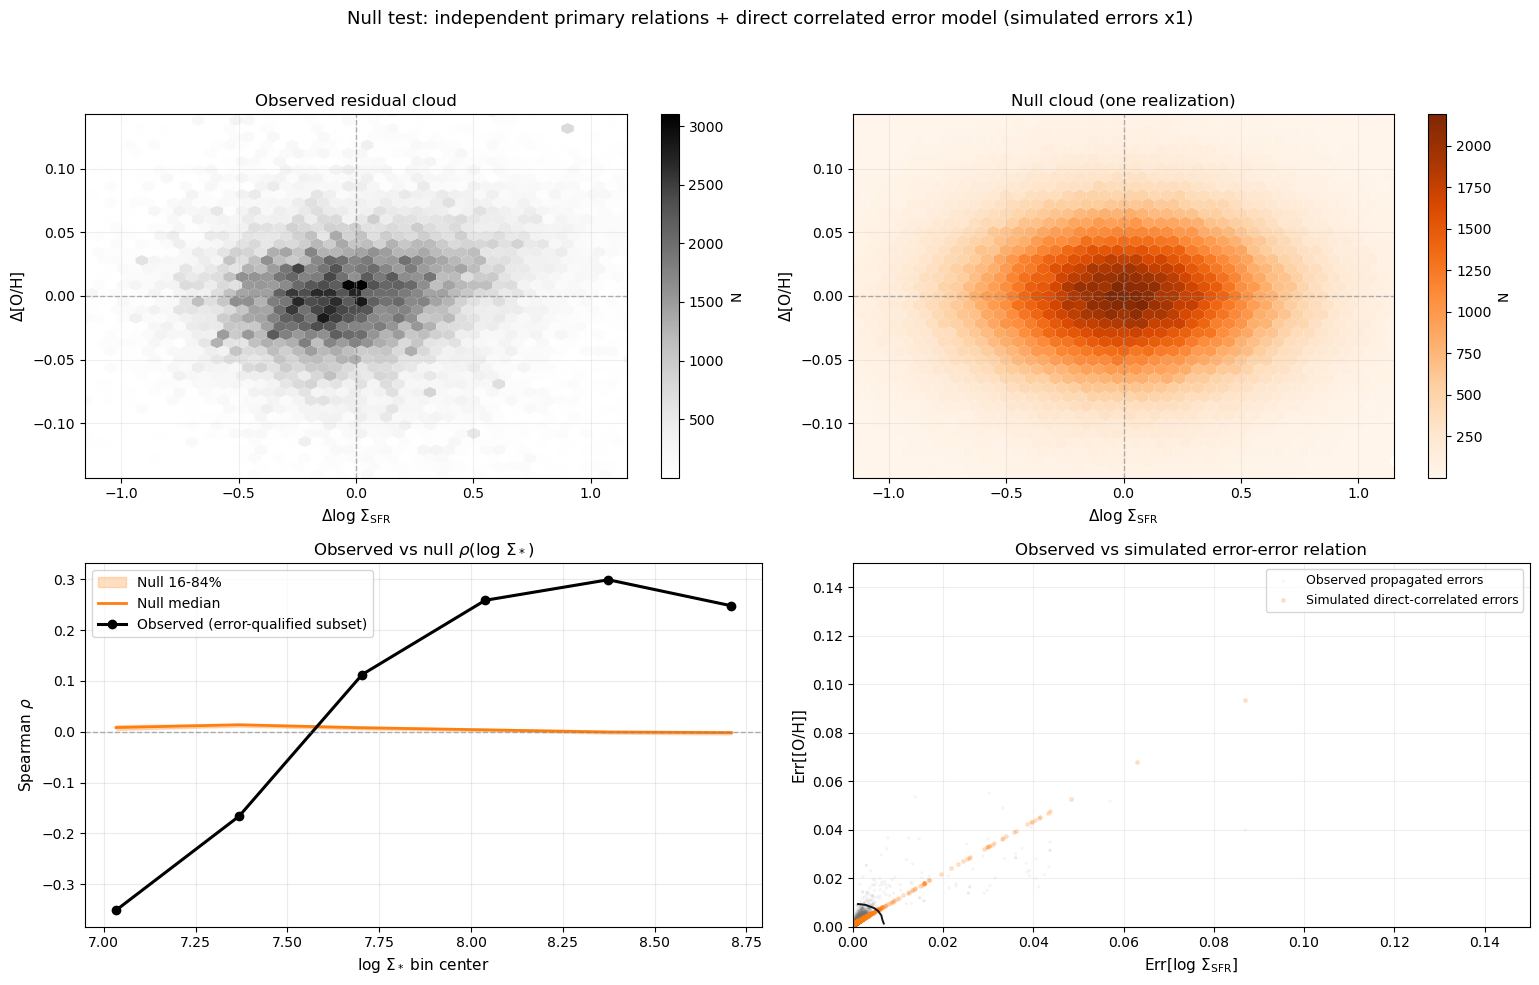

In [2]:
# ------------------------------------------------------------------
# Strengthened null test following Sanchez et al. (2021) Sec. 3.4
# ------------------------------------------------------------------
import numpy as np

from sec34_null_test_20260408 import (
    compute_rho_curve_from_pipeline,
    load_o3n2_m13_hii_sample_with_errors,
    make_percentile_mass_bin_edges,
    mask_sample,
    plot_sec34_style_null_test,
    print_sec34_summary,
    run_sec34_style_null_test,
)

required = [
    "global_sigM",
    "global_sigSFR",
    "global_oh",
    "global_bin_centers",
    "global_rho_values",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError("Run the global residual-analysis cell first. Missing variables: " + ", ".join(missing))

# ------------------------------------------------------------------
# 1. Silent consistency check against the existing global pipeline
# ------------------------------------------------------------------
global_mass_bin_edges = make_percentile_mass_bin_edges(
    global_sigM,
    n_bins=6,
    lower_percentile=2.5,
    upper_percentile=97.5,
)

global_check = compute_rho_curve_from_pipeline(
    global_sigM,
    global_sigSFR,
    global_oh,
    mass_bin_edges=global_mass_bin_edges,
    bin_width=0.2,
    min_unique=20,
    min_trend_points=3,
)

expected_centers = np.asarray(global_bin_centers, dtype=float)
expected_rho = np.asarray(global_rho_values, dtype=float)
helper_centers = np.asarray(global_check["centers"], dtype=float)
helper_rho = np.asarray(global_check["rho"], dtype=float)
helper_valid = np.isfinite(helper_rho)
helper_centers = helper_centers[helper_valid]
helper_rho = helper_rho[helper_valid]

if expected_centers.size != helper_centers.size:
    raise RuntimeError(
        "Silent validation failed: the helper did not recover the same number of valid global rho bins."
    )

stored_order = np.argsort(expected_centers)
helper_order = np.argsort(helper_centers)
expected_centers = expected_centers[stored_order]
expected_rho = expected_rho[stored_order]
helper_centers = helper_centers[helper_order]
helper_rho = helper_rho[helper_order]

if not np.allclose(expected_centers, helper_centers, atol=1e-10, equal_nan=True):
    raise RuntimeError("Silent validation failed: the helper recovered different mass-bin centers.")

if not np.allclose(expected_rho, helper_rho, atol=1e-12, equal_nan=True):
    raise RuntimeError("Silent validation failed: the helper did not reproduce the expected rho values.")

# ------------------------------------------------------------------
# 2. Build the propagated-error sample used by the null test
# ------------------------------------------------------------------
sec34_full = load_o3n2_m13_hii_sample_with_errors(excluded_galaxies={"NGC4383"})
finite_error_mask = np.isfinite(sec34_full["sigma_log_sfr"]) & np.isfinite(sec34_full["sigma_oh"])
sec34_sample = mask_sample(sec34_full, finite_error_mask)

print("=" * 100)
print(f"Simulation sample with finite propagated uncertainties: {np.sum(finite_error_mask)}")
print(f"Fraction retained after requiring finite propagated uncertainties: {np.sum(finite_error_mask) / global_sigM.size:.3f}")
print("The same 6 global mass bins are used for the observed sample and all null realizations.")
print("=" * 100)

# ------------------------------------------------------------------
# 3. Run the Sec. 3.4-style null test with the global mass bins
# ------------------------------------------------------------------
sec34_result = run_sec34_style_null_test(
    sec34_sample,
    mass_bin_edges=global_mass_bin_edges,
    n_realizations=100,
    random_seed=726,
    include_mass_error_proxy=True,
    mass_error_base=0.01,
)

print_sec34_summary(sec34_result)
plot_sec34_style_null_test(sec34_result)


### Per-Galaxy Sec. 3.4 Panels

This cell runs the same Sec. 3.4-style null-test logic galaxy by galaxy, now using each galaxy's own fitted `sigma([O/H])`-`sigma(log Sigma_SFR)` line as the direct correlated-error model. Each galaxy gets three panels: the observed residual cloud, one null realization, and the galaxy-specific `rho(log Sigma_*)` trend. The black observed curve and the orange null envelope use the same galaxy-specific mass-bin edges, with those edges defined once from the observed galaxy and then reused for all null realizations of that galaxy. In the trend panel, the orange null envelope is masked to the same bins where the observed black curve is defined, so the visual comparison is made only over the bins that survive the observed Spearman-quality cut. The blue dotted curve is the combined observed trend for comparison only, so it keeps the global ensemble binning and does not need to land at the same x positions as the galaxy-specific black and orange curves. `NGC4383` is shown with a dashed black observed line because it is not included in the ensemble trend.


/Users/Igniz/Desktop/ICRAR/extended/sec34_null_test_20260408.py:611: RuntimeWarning: All-NaN slice encountered
  "median_rho": np.nanmedian(rho_matrix, axis=0),
/opt/miniconda3/envs/ICRAR/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


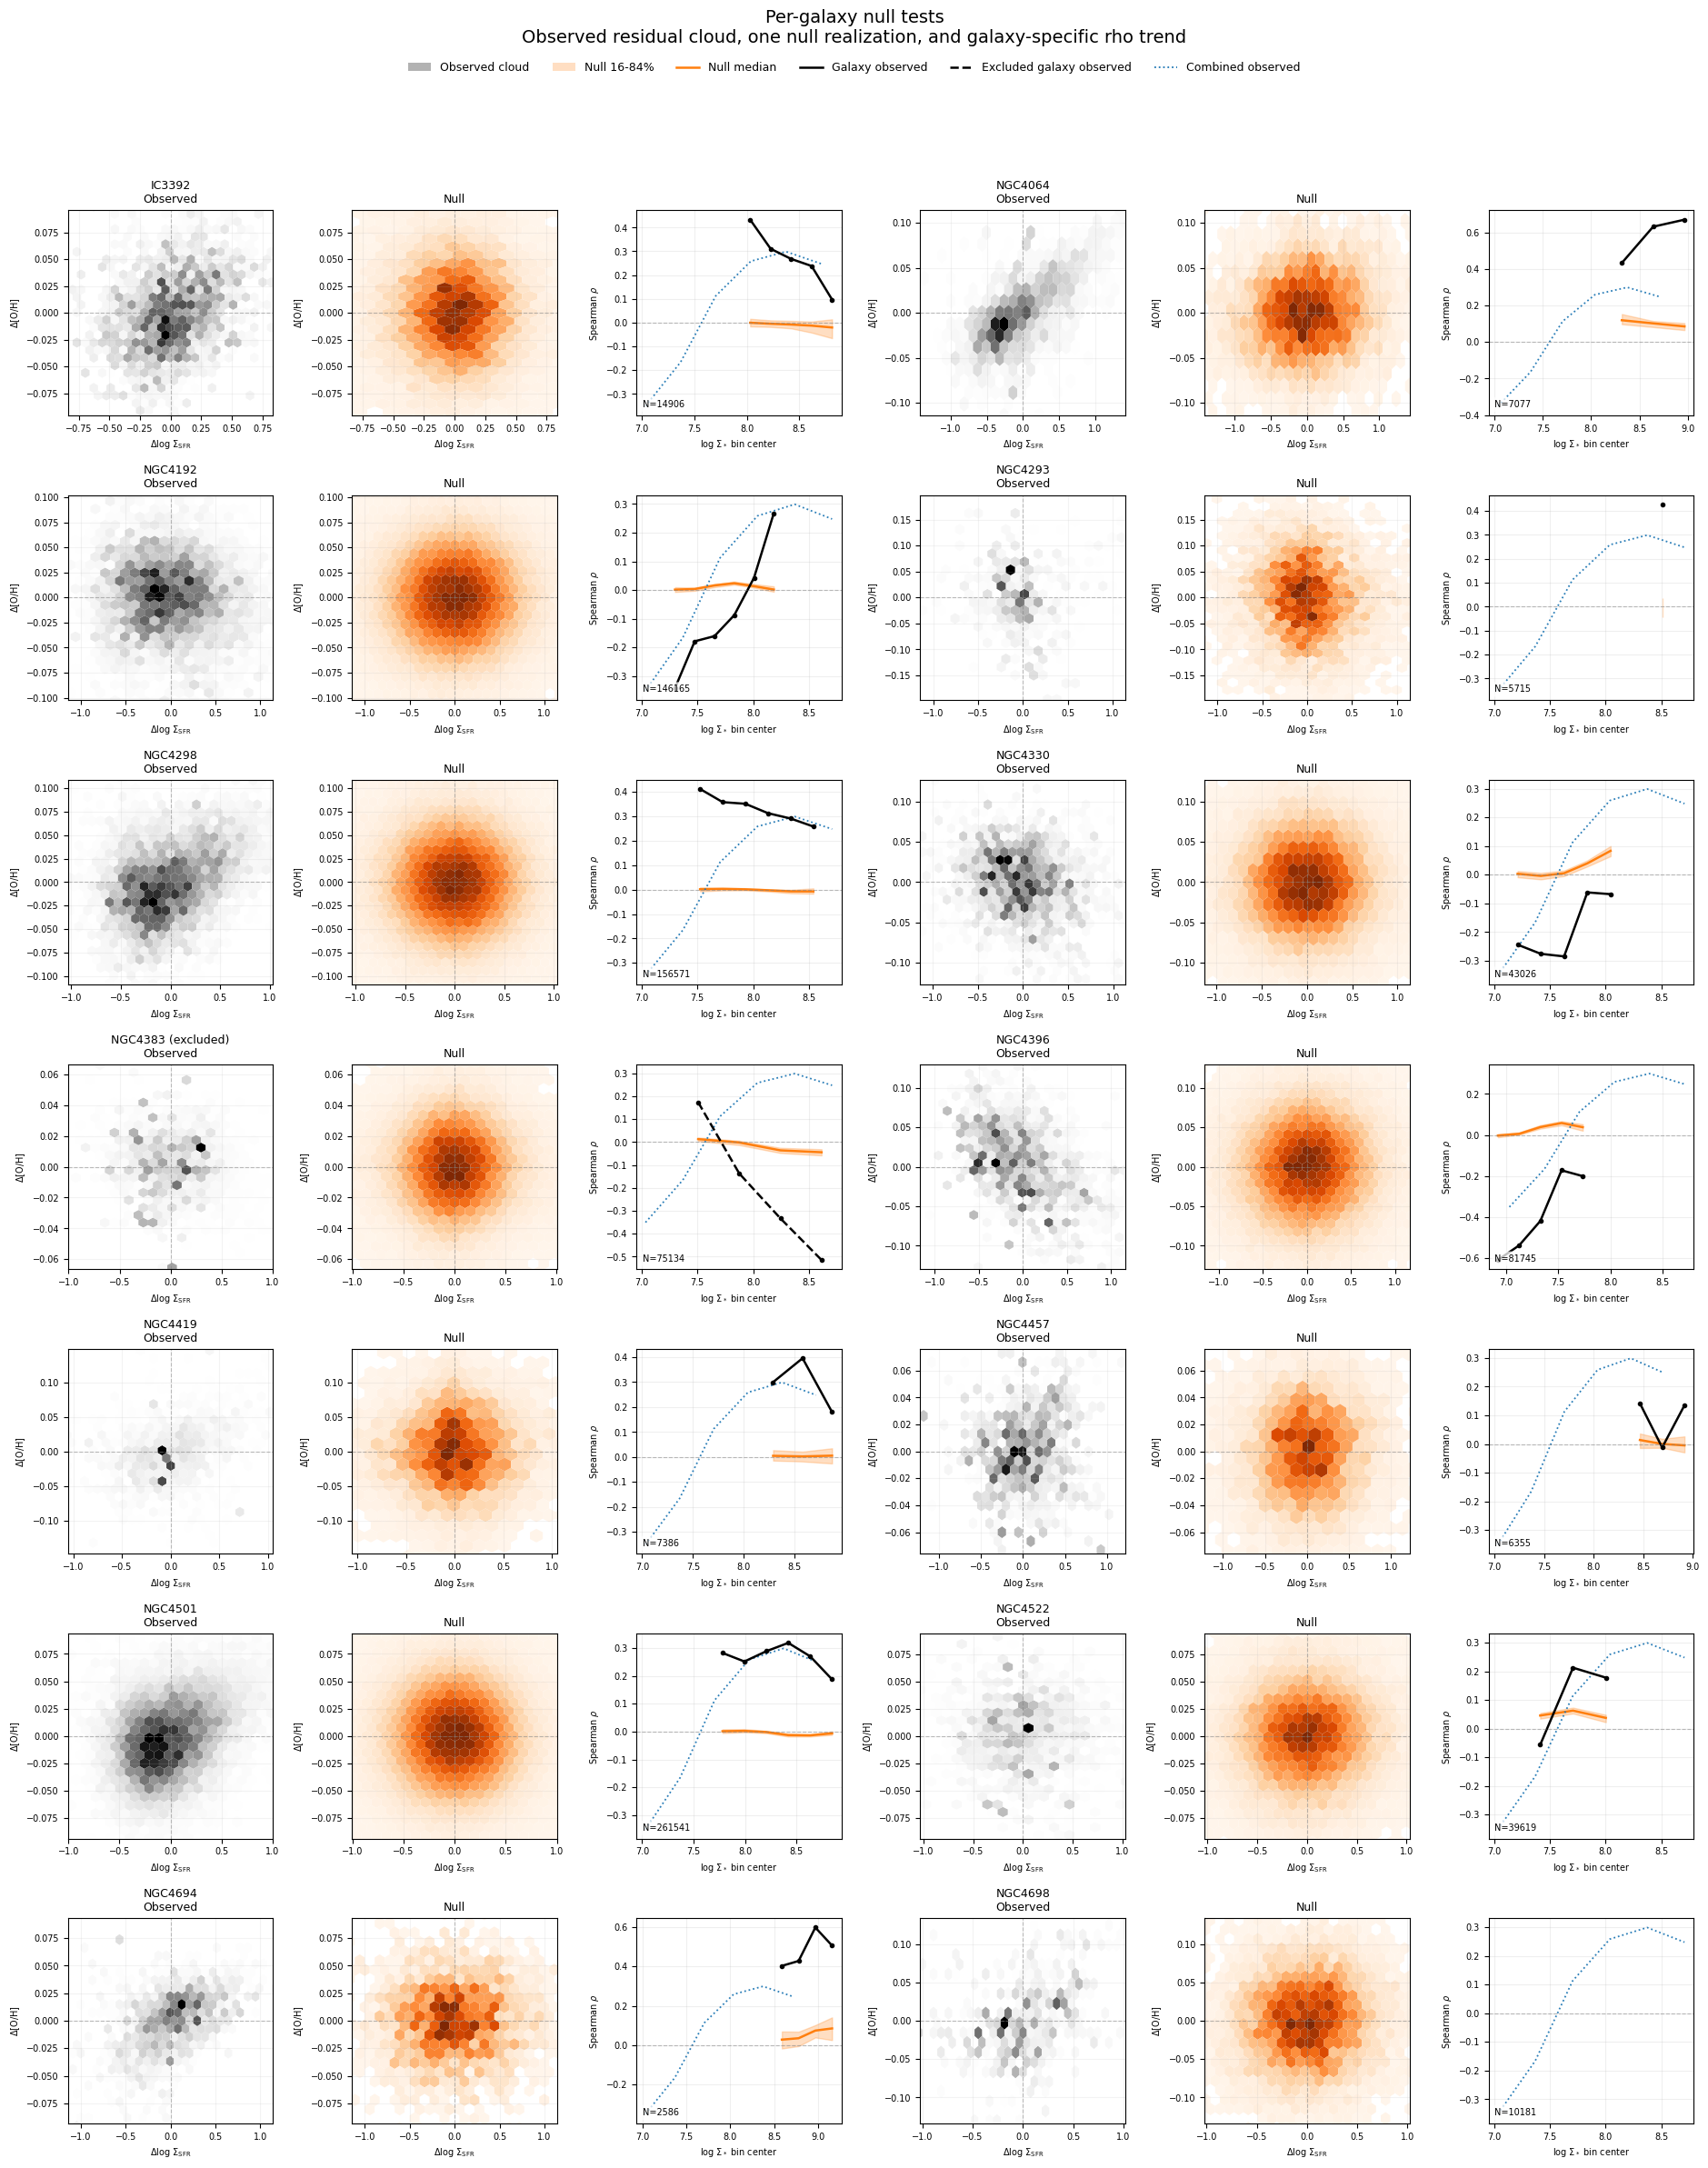

In [3]:
# ------------------------------------------------------------------
# Per-galaxy Sec. 3.4-style null tests in a 7x6 panel grid
# ------------------------------------------------------------------
import numpy as np

from sec34_null_test_20260408 import (
    list_available_galaxies,
    load_o3n2_m13_hii_sample_with_errors,
    mask_sample,
    plot_sec34_galaxy_grid,
    run_sec34_style_null_test_by_galaxy,
)

required = ["global_sigM", "global_bin_centers", "global_rho_values"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError("Run the global residual-analysis cell first. Missing variables: " + ", ".join(missing))

all_sec34 = load_o3n2_m13_hii_sample_with_errors(excluded_galaxies=())
finite_error_mask_all = np.isfinite(all_sec34["sigma_log_sfr"]) & np.isfinite(all_sec34["sigma_oh"])
all_sec34 = mask_sample(all_sec34, finite_error_mask_all)

galaxy_order = list_available_galaxies()
per_gal_sec34 = run_sec34_style_null_test_by_galaxy(
    all_sec34,
    galaxy_order=galaxy_order,
    n_bins=6,
    n_realizations=100,
    random_seed=726,
    include_mass_error_proxy=True,
    mass_error_base=0.05,
)

combined_curve = {
    "centers": np.asarray(global_bin_centers, dtype=float),
    "rho": np.asarray(global_rho_values, dtype=float),
    "label": "Combined observed",
}

plot_sec34_galaxy_grid(
    per_gal_sec34["galaxy_results"],
    galaxy_order=per_gal_sec34["galaxy_order"],
    combined_curve=combined_curve,
    excluded_galaxies={"NGC4383"},
)


### Simulated Moran Maps for NGC4501 and NGC4192

This cell draws one null realization for each selected galaxy from the Sec. 3.4 simulation and maps the simulated spaxel values back onto the original footprint. Those realizations now use the same direct correlated-error construction, with `sigma([O/H])` forced onto the galaxy's fitted `sigma([O/H])`-`sigma(log Sigma_SFR)` line. The offset maps use 12 local `Sigma_*` bins, and the Moran-like panel follows the same local bivariate statistic and symmetric-log color scaling used in `20260202_Moran_MAUVE14.ipynb`.


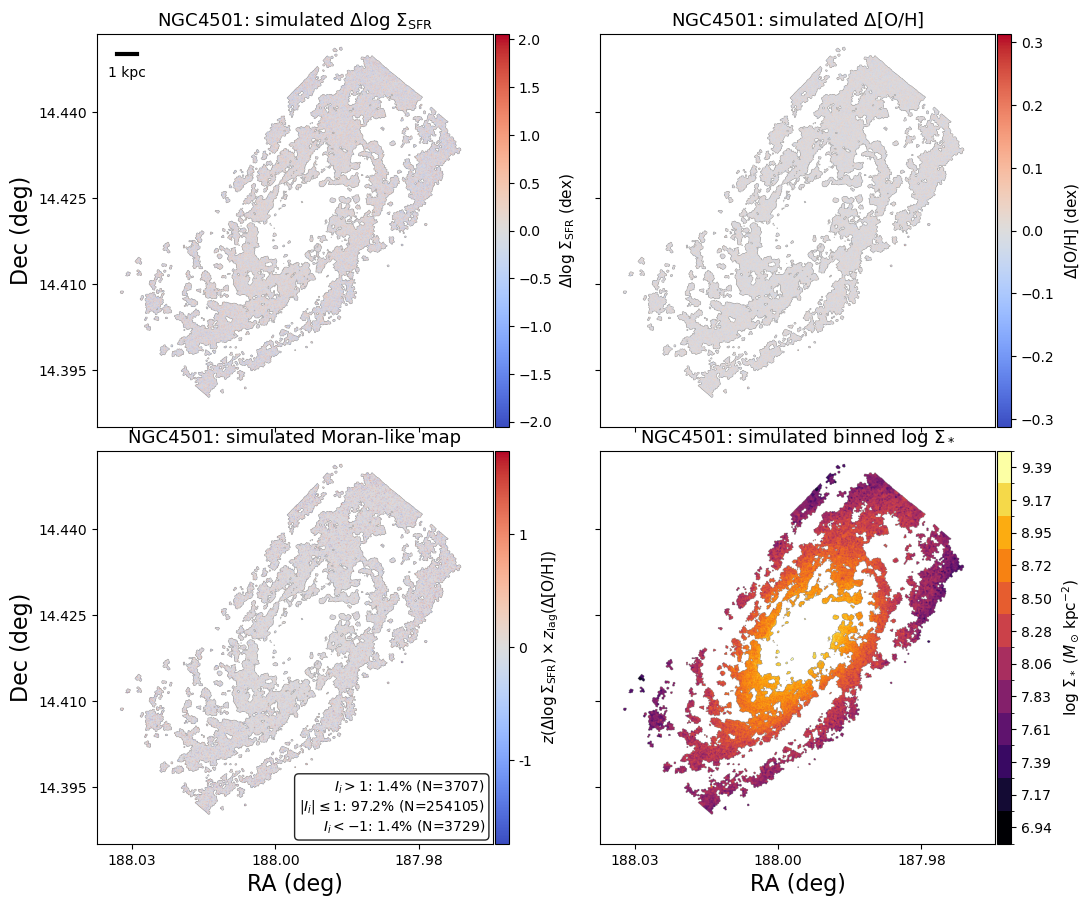

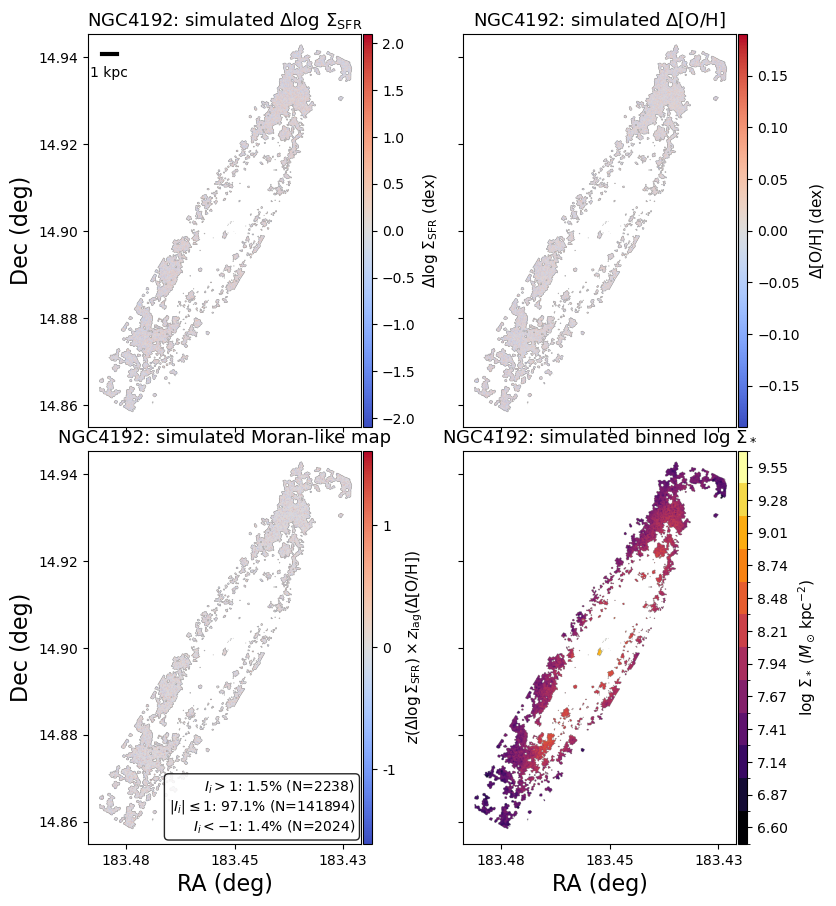

In [4]:
# ------------------------------------------------------------------
# Simulated 2x2 Moran-style maps for selected galaxies
# ------------------------------------------------------------------
from sec34_null_test_20260408 import build_simulated_moran_maps_for_galaxy, plot_simulated_moran_2x2

simulated_moran_targets = {
    "NGC4501": 4501,
    "NGC4192": 4192,
}

simulated_moran_results = {}
for galaxy, seed in simulated_moran_targets.items():
    simulated_moran_results[galaxy] = build_simulated_moran_maps_for_galaxy(
        galaxy,
        random_seed=seed,
        null_n_bins=6,
        offset_n_bins=12,
        include_mass_error_proxy=True,
        mass_error_base=0.05,
        neighbourhood="queen",
        threshold=1.0,
    )
    plot_simulated_moran_2x2(simulated_moran_results[galaxy])


## Check rMZR


STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14906 pixels
  NGC4064: HII=7077 pixels
  NGC4192: HII=146165 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156571 pixels
  NGC4330: HII=43026 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7386 pixels
  NGC4457: HII=6355 pixels
  NGC4501: HII=261541 pixels
  NGC4522: HII=39619 pixels
  NGC4694: HII=2586 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 782873

STEP 2: Defining 8 SFR bins for rMZR
  Bin 1: <-3.5
  Bin 2: -3.5–-3.0
  Bin 3: -3.0–-2.5
  Bin 4: -2.5–-2.0
  Bin 5: -2.0–-1.5
  Bin 6: -1.5–-1.0
  Bin 7: -1.0–-0.5
  Bin 8: >-0.5

STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR
  Bin 1: <6.5
  Bin 2: 6.5–7.0
  Bin 3: 7.0–7.5
  Bin 4: 7.5–8.0
  Bin 5: 8.0–8.5
  Bin 6: 8.5–9.0
  Bin 7: 9.0–9.5
  Bin 8: >9.5

STEP 4: Creating combined 2x2 plot (O3N2-M13 only)

Using uniform y-axis range: 8.2 to 8.9

Processing O3N2-M13 calibration for HII r

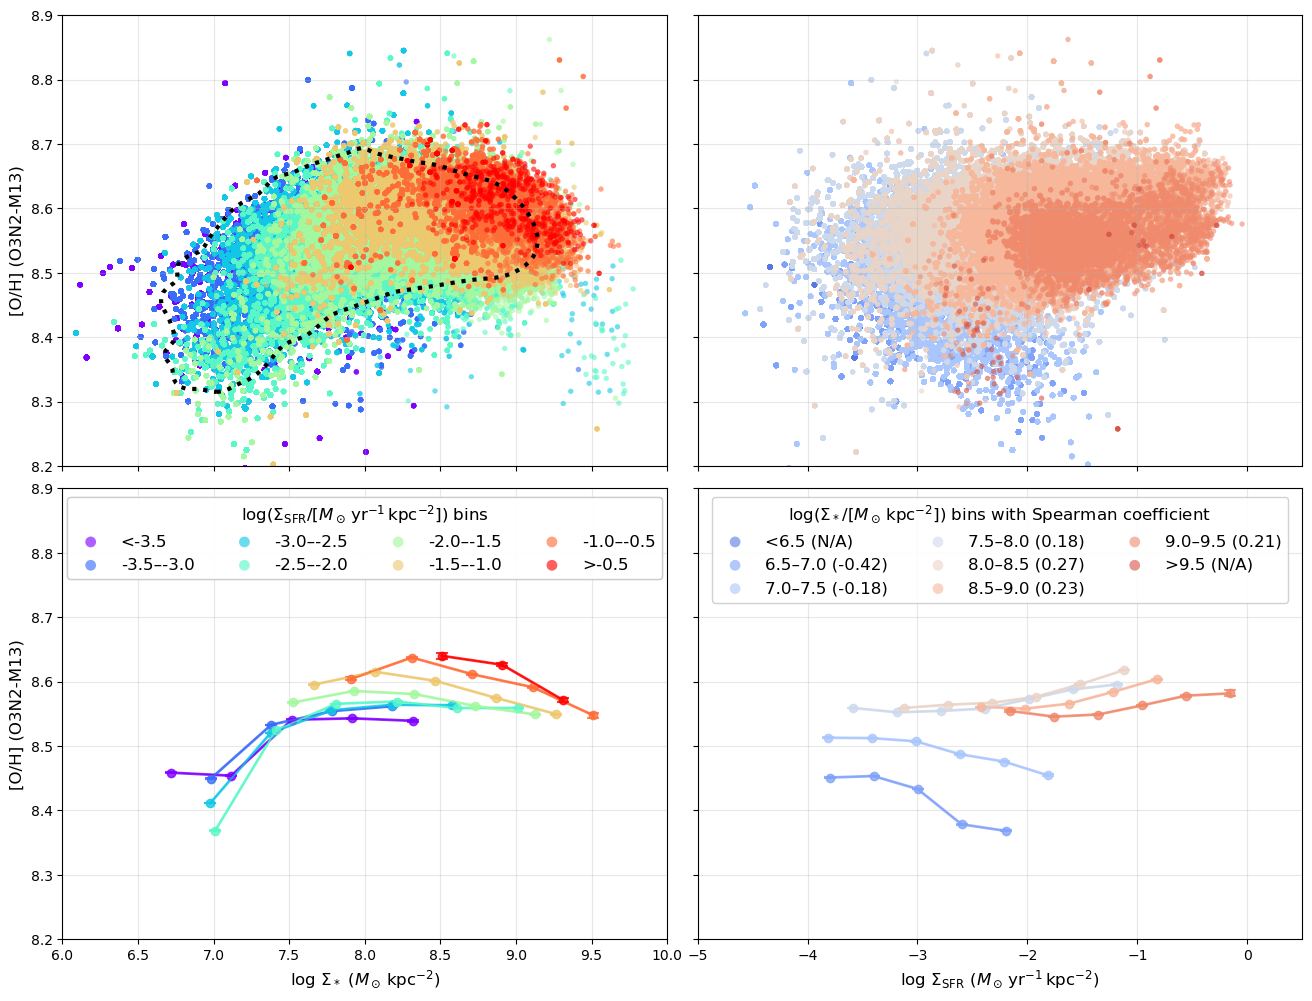


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)
  Bottom-left: rMZR median trends (8 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [5]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
import scipy.ndimage as ndimage
from scipy.optimize import curve_fit

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.4, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= min_pixels unique datapoints"""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    return (np.array(valid_centers), np.array(medians), np.array(stds), np.array(counts), np.array(valid_bin_indices))

def mzr_model(x, a, b, c):
    return a + b * (x - c) * np.exp(-(x - c))

def compute_density_mask(x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0, return_contour=False):
    """Return mask for points inside the 95% density contour within given ranges."""
    mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    if not np.any(mask_finite):
        empty_mask = np.zeros_like(x_vals, dtype=bool)
        return (empty_mask, None, None) if return_contour else empty_mask
    x = x_vals[mask_finite]
    y = y_vals[mask_finite]
    H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
    H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
    H_flat = np.sort(H_smooth.ravel())[::-1]
    H_cumsum = np.cumsum(H_flat)
    level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
    level_95 = H_flat[level_idx]
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)
    dx = (x_range[1] - x_range[0]) / nbins
    dy = (y_range[1] - y_range[0]) / nbins
    x_idx = (x - x_range[0]) / dx - 0.5
    y_idx = (y - y_range[0]) / dy - 0.5
    densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
    mask_local = densities >= level_95
    full_mask = np.zeros_like(x_vals, dtype=bool)
    full_mask[np.where(mask_finite)[0]] = mask_local
    if return_contour:
        return full_mask, level_95, (X, Y, H_smooth)
    return full_mask

def plot_literature_mzr_fits(ax, show_legend=True):
    plot_data = []
    x_sanchez = np.linspace(7.05, 9.15, 200)
    a5, b5, c5 = 8.74, 0.013, 9.50
    y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
    plot_data.append((x_sanchez, y_sanchez13, 'Sánchez+13', ':', 'olive'))
    x_bb = np.linspace(7., 8.9, 200)
    a2, b2, c2 = 8.55, 0.014, 9.14
    y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
    plot_data.append((x_bb, y_bb16, 'Barrera-Ballesteros+16', '--', 'brown'))
    x_ef = np.linspace(6.5, 10.0, 200)
    a4, b4, c4 = 8.61, 0.008, 10.0
    y_ef17 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
    plot_data.append((x_ef, y_ef17, 'Erroz-Ferrer+17', '-.', 'pink'))
    for x, y, label, linestyle, color in plot_data:
        ax.plot(x, y, label=label if show_legend else None, linewidth=2, linestyle=linestyle, color=color)

bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}
included_galaxies = []
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue
    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & np.isfinite(oh_o3n2_m13_HII))
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

print("\n" + "="*80)
print("STEP 2: Defining 8 SFR bins for rMZR")
print("="*80)
n_bins = 8
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
bin_labels = ['<-3.5', '-3.5–-3.0', '-3.0–-2.5', '-2.5–-2.0', '-2.0–-1.5', '-1.5–-1.0', '-1.0–-0.5', '>-0.5']
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

print("\n" + "="*80)
print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
print("="*80)
n_bins_sigmaM = 8
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]
bin_labels_sigmaM = ['<6.5', '6.5–7.0', '7.0–7.5', '7.5–8.0', '8.0–8.5', '8.5–9.0', '9.0–9.5', '>9.5']
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("="*80)
common_ylim = (8.2, 8.9)
x_range_rMZR = (6, 10)
x_range_Zgas = (-5.0, 0.5)
print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
plt.subplots_adjust(wspace=0.05, hspace=0.05)
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'
print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

mask_95_all_rMZR, level_95_all_rMZR, contour_data_rMZR = compute_density_mask(all_logSigmaM_HII, oh_data_HII, x_range_rMZR, common_ylim, return_contour=True)
max_typical_yerr_rMZR = np.nan
max_typical_yerr_Zgas = np.nan

print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")
legend_handles_sfr, legend_labels_sfr = [], []
valid_bins_rMZR = 0
for i in range(n_bins):
    in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i + 1])
    n_pixels_HII = np.sum(in_bin_HII)
    if n_pixels_HII >= 10:
        x_bin_all = all_logSigmaM_HII[in_bin_HII]
        y_bin_all = oh_data_HII[in_bin_HII]
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sfr[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_rMZR, common_ylim)
        x_bin = x_bin_all[mask_95_bin]
        y_bin = y_bin_all[mask_95_bin]
        if len(x_bin) >= 10:
            mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_bin, y_bin, bin_width=0.4, min_pixels=20)
            if len(mass_centers_HII) > 1:
                yerr_HII = stds_HII / np.sqrt(counts_HII)
                typical_yerr = np.nanmedian(yerr_HII)
                print(f"    rMZR bin {i+1} {bin_labels[i]}: typical yerr (median σ/√N) = {typical_yerr:.4f}")
                if np.isfinite(typical_yerr):
                    max_typical_yerr_rMZR = np.nanmax([max_typical_yerr_rMZR, typical_yerr])
                ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=yerr_HII, color=colors_sfr[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                for j in range(len(valid_bin_indices_HII) - 1):
                    current_bin_idx = valid_bin_indices_HII[j]
                    next_bin_idx = valid_bin_indices_HII[j + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sfr[i], linewidth=2, alpha=0.8)
                valid_bins_rMZR += 1

if contour_data_rMZR is not None and level_95_all_rMZR is not None:
    ax_rMZR_scatter.contour(contour_data_rMZR[0], contour_data_rMZR[1], contour_data_rMZR[2].T, levels=[level_95_all_rMZR], colors='k', linewidths=3, linestyles=':')
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(*x_range_rMZR)
ax_rMZR_scatter.set_ylim(common_ylim)
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(*x_range_rMZR)
ax_rMZR_median.set_ylim(common_ylim)
legend1 = ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', ncol=4, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_\mathrm{SFR}/[M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2}])$ bins', title_fontsize=12)
legend1_handles = getattr(legend1, "legend_handles", None)
if legend1_handles is None:
    legend1_handles = getattr(legend1, "legendHandles", [])
for handle in legend1_handles:
    try:
        handle.set_sizes([60])
    except Exception:
        pass
ax_rMZR_median.add_artist(legend1)
# if np.isfinite(max_typical_yerr_rMZR):
#     ax_rMZR_median.errorbar(x_range_rMZR[0] + 0.2, common_ylim[0] + 0.05, yerr=max_typical_yerr_rMZR, color='k', marker='o', markersize=4, linewidth=1, capsize=4, capthick=1.5)
print(f"  rMZR valid bins: {valid_bins_rMZR}")

print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")
legend_handles_sigmaM, legend_labels_sigmaM_display = [], []
valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i + 1])
    n_pixels_HII = np.sum(in_bin_HII)
    if n_pixels_HII >= 10:
        x_bin_all = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_all = oh_data_HII[in_bin_HII]
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sigmaM[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
        legend_handles_sigmaM.append(scatter_hii)
        mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_Zgas, common_ylim)
        x_bin = x_bin_all[mask_95_bin]
        y_bin = y_bin_all[mask_95_bin]
        spearman_text = "N/A"
        if len(x_bin) > 1:
            y_mean, y_std = np.nanmean(y_bin), np.nanstd(y_bin)
            x_mean, x_std = np.nanmean(x_bin), np.nanstd(x_bin)
            mask_clip = (np.abs(y_bin - y_mean) < 3 * y_std) & (np.abs(x_bin - x_mean) < 3 * x_std)
            x_clipped = x_bin[mask_clip]
            y_clipped = y_bin[mask_clip]
            sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_clipped, y_clipped, bin_width=0.4, min_pixels=20)
            if len(sfr_centers_HII) > 1:
                if len(x_clipped) > 10:
                    corr, _ = stats.spearmanr(x_clipped, y_clipped)
                    spearman_text = f"{corr:.2f}"
                yerr_HII = stds_HII / np.sqrt(counts_HII)
                typical_yerr = np.nanmedian(yerr_HII)
                print(f"    Zgas-ΣSFR bin {i+1} {bin_labels_sigmaM[i]}: typical yerr (median σ/√N) = {typical_yerr:.4f}")
                if np.isfinite(typical_yerr):
                    max_typical_yerr_Zgas = np.nanmax([max_typical_yerr_Zgas, typical_yerr])
                ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=yerr_HII, color=colors_sigmaM[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                for j in range(len(valid_bin_indices_HII) - 1):
                    current_bin_idx = valid_bin_indices_HII[j]
                    next_bin_idx = valid_bin_indices_HII[j + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sigmaM[i], linewidth=2, alpha=0.8)
                valid_bins_Zgas += 1
        legend_labels_sigmaM_display.append(f"{bin_labels_sigmaM[i]} ({spearman_text})")

ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(*x_range_Zgas)
ax_Zgas_scatter.set_ylim(common_ylim)
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(*x_range_Zgas)
ax_Zgas_median.set_ylim(common_ylim)
legend2 = ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', ncol=3, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_*/[M_\odot\,\mathrm{kpc}^{-2}])$ bins with Spearman coefficient', title_fontsize=12)
legend2_handles = getattr(legend2, "legend_handles", None)
if legend2_handles is None:
    legend2_handles = getattr(legend2, "legendHandles", [])
for handle in legend2_handles:
    try:
        handle.set_sizes([60])
    except Exception:
        pass
# if np.isfinite(max_typical_yerr_Zgas):
#     ax_Zgas_median.errorbar(x_range_Zgas[0] + 0.2, common_ylim[0] + 0.05, yerr=max_typical_yerr_Zgas, color='k', marker='o', markersize=4, linewidth=1, capsize=4, capthick=1.5)
print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

STEP 1: Building simulated sample with exact per-mass-bin count matching
  Mass bin 1: n_obs=2816, n_sim=2816
  Mass bin 2: n_obs=35850, n_sim=35850
  Mass bin 3: n_obs=116657, n_sim=116657
  Mass bin 4: n_obs=277673, n_sim=277673
  Mass bin 5: n_obs=240945, n_sim=240945
  Mass bin 6: n_obs=102467, n_sim=102467
  Mass bin 7: n_obs=6401, n_sim=6401
  Mass bin 8: n_obs=64, n_sim=64
--------------------------------------------------------------------------------
Total non-NaN spaxels (observed): 782873
Total non-NaN spaxels (simulated): 782873
Observed per-mass-bin counts: [  2816  35850 116657 277673 240945 102467   6401     64]
Simulated per-mass-bin counts: [  2816  35850 116657 277673 240945 102467   6401     64]
Count check passed: observed and simulated data have identical total and per-mass-bin spaxel counts.

STEP 2: Defining 8 SFR bins for rMZR
  Bin 1: <-3.5
  Bin 2: -3.5–-3.0
  Bin 3: -3.0–-2.5
  Bin 4: -2.5–-2.0
  Bin 5: -2.0–-1.5
  Bin 6: -1.5–-1.0
  Bin 7: -1.0–-0.5
  Bin 8:

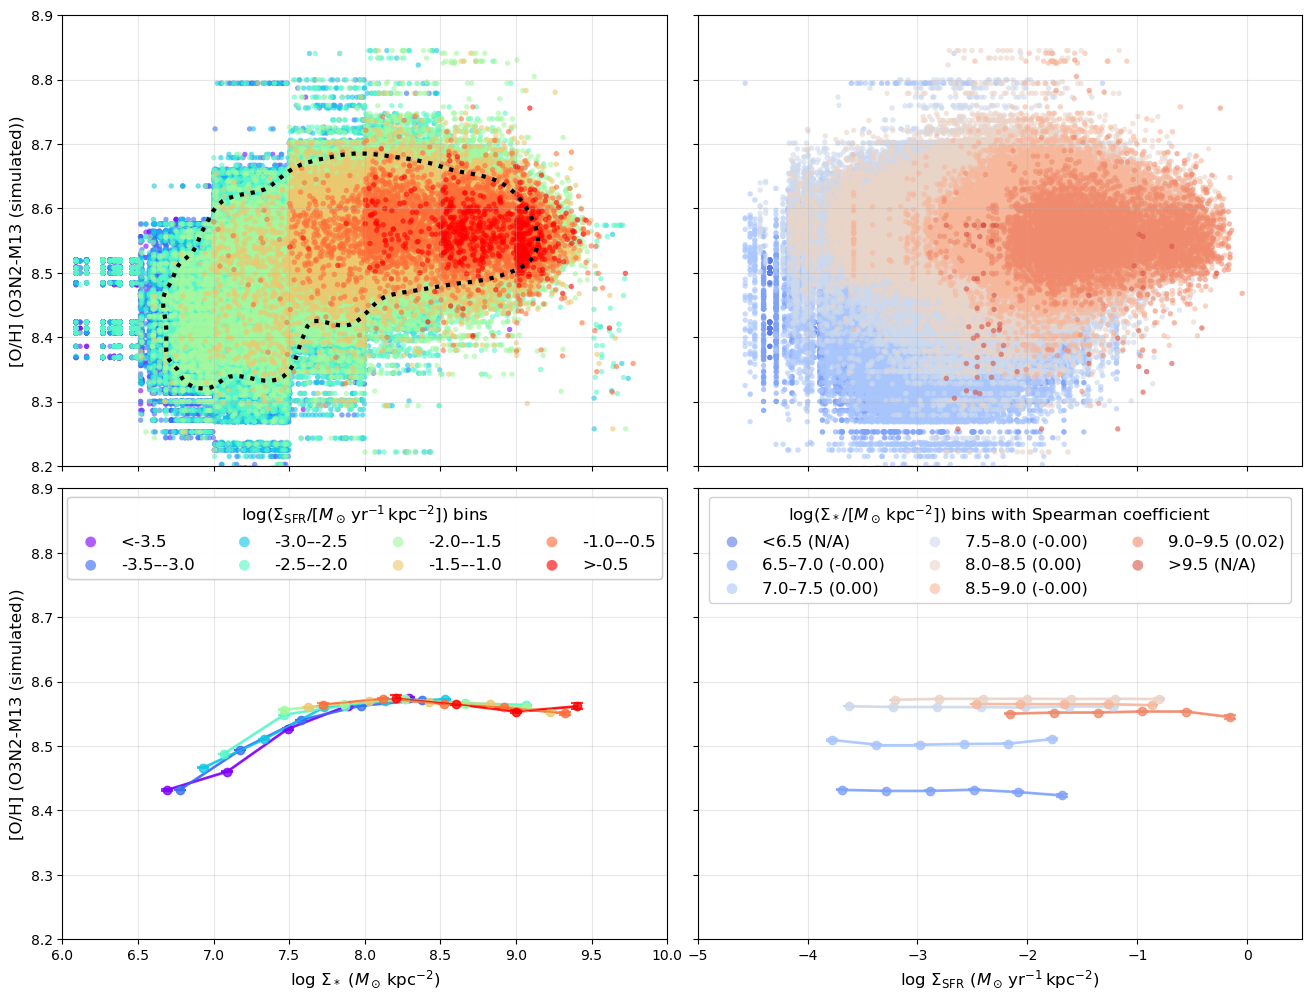


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (SIMULATED O3N2-M13)
Successfully created 2x2 subplot figure for simulated HII regions based on 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Σ_SFR bins, simulated)
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins, simulated)
  Bottom-left: rMZR median trends (8 Σ_SFR bins, simulated)
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins, simulated)
  Shared y-range: 8.2 to 8.9


In [6]:
# ------------------------------------------------------------------
# Simulated Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# Same 2x2 procedure as Cell 11, but with simulated data
# while enforcing exact observed-vs-simulated spaxel counts per Σ_* bin.
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

required_vars = [
    "all_logSigmaM_HII",
    "all_logSigmaSFR_HII",
    "all_oh_o3n2_m13_HII",
    "included_galaxies",
    "excluded_galaxies",
]
missing_vars = [name for name in required_vars if name not in globals()]
if missing_vars:
    raise RuntimeError("Run Cell 11 first. Missing variables: " + ", ".join(missing_vars))

required_funcs = ["calculate_binned_stats", "compute_density_mask"]
missing_funcs = [name for name in required_funcs if name not in globals()]
if missing_funcs:
    raise RuntimeError("Run Cell 11 first. Missing helper functions: " + ", ".join(missing_funcs))

# ------------------------------------------------------------------
# STEP 1: Build a simulated sample with exact per-mass-bin occupancy
# ------------------------------------------------------------------
obs_mask = (
    np.isfinite(all_logSigmaM_HII)
    & np.isfinite(all_logSigmaSFR_HII)
    & np.isfinite(all_oh_o3n2_m13_HII)
)

obs_logSigmaM = np.asarray(all_logSigmaM_HII[obs_mask], dtype=float)
obs_logSigmaSFR = np.asarray(all_logSigmaSFR_HII[obs_mask], dtype=float)
obs_oh = np.asarray(all_oh_o3n2_m13_HII[obs_mask], dtype=float)

# Same Σ_* bin definition used by the observed Cell 11 analysis.
sigmaM_bin_edges_match = np.array([-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf], dtype=float)
rng = np.random.default_rng(726)

sim_logSigmaM = obs_logSigmaM.copy()
sim_logSigmaSFR = np.full_like(obs_logSigmaSFR, np.nan)
sim_oh = np.full_like(obs_oh, np.nan)

print("=" * 80)
print("STEP 1: Building simulated sample with exact per-mass-bin count matching")
print("=" * 80)

for i in range(len(sigmaM_bin_edges_match) - 1):
    left = sigmaM_bin_edges_match[i]
    right = sigmaM_bin_edges_match[i + 1]
    in_bin = (obs_logSigmaM >= left) & (obs_logSigmaM < right)

    n_obs_bin = int(np.sum(in_bin))
    if n_obs_bin == 0:
        print(f"  Mass bin {i+1}: n_obs=0, n_sim=0")
        continue

    y_obs_bin = obs_logSigmaSFR[in_bin]
    z_obs_bin = obs_oh[in_bin]

    # Independent within-bin resampling keeps N exactly fixed in every bin.
    sim_logSigmaSFR[in_bin] = rng.choice(y_obs_bin, size=n_obs_bin, replace=True)
    sim_oh[in_bin] = rng.choice(z_obs_bin, size=n_obs_bin, replace=True)

    n_sim_bin = int(np.sum(np.isfinite(sim_logSigmaSFR[in_bin]) & np.isfinite(sim_oh[in_bin])))
    print(f"  Mass bin {i+1}: n_obs={n_obs_bin}, n_sim={n_sim_bin}")

obs_total = int(np.sum(np.isfinite(obs_logSigmaM) & np.isfinite(obs_logSigmaSFR) & np.isfinite(obs_oh)))
sim_total = int(np.sum(np.isfinite(sim_logSigmaM) & np.isfinite(sim_logSigmaSFR) & np.isfinite(sim_oh)))

obs_counts = []
sim_counts = []
for i in range(len(sigmaM_bin_edges_match) - 1):
    left = sigmaM_bin_edges_match[i]
    right = sigmaM_bin_edges_match[i + 1]

    obs_in_bin = (
        (obs_logSigmaM >= left)
        & (obs_logSigmaM < right)
        & np.isfinite(obs_logSigmaSFR)
        & np.isfinite(obs_oh)
    )
    sim_in_bin = (
        (sim_logSigmaM >= left)
        & (sim_logSigmaM < right)
        & np.isfinite(sim_logSigmaSFR)
        & np.isfinite(sim_oh)
    )

    obs_counts.append(int(np.sum(obs_in_bin)))
    sim_counts.append(int(np.sum(sim_in_bin)))

obs_counts = np.asarray(obs_counts, dtype=int)
sim_counts = np.asarray(sim_counts, dtype=int)

print("-" * 80)
print(f"Total non-NaN spaxels (observed): {obs_total}")
print(f"Total non-NaN spaxels (simulated): {sim_total}")
print("Observed per-mass-bin counts:", obs_counts)
print("Simulated per-mass-bin counts:", sim_counts)

if sim_total != obs_total:
    raise RuntimeError("Total non-NaN spaxel count mismatch between observed and simulated samples.")
if not np.array_equal(obs_counts, sim_counts):
    raise RuntimeError("Per-mass-bin spaxel counts mismatch between observed and simulated samples.")

print("Count check passed: observed and simulated data have identical total and per-mass-bin spaxel counts.")

all_logSigmaM_HII_sim = sim_logSigmaM
all_logSigmaSFR_HII_sim = sim_logSigmaSFR
all_oh_o3n2_m13_HII_sim = sim_oh

# ------------------------------------------------------------------
# STEP 2: Defining 8 SFR bins for rMZR (same as Cell 11)
# ------------------------------------------------------------------
print("\n" + "="*80)
print("STEP 2: Defining 8 SFR bins for rMZR")
print("="*80)
n_bins = 8
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
bin_labels = ['<-3.5', '-3.5–-3.0', '-3.0–-2.5', '-2.5–-2.0', '-2.0–-1.5', '-1.5–-1.0', '-1.0–-0.5', '>-0.5']
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# ------------------------------------------------------------------
# STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR (same as Cell 11)
# ------------------------------------------------------------------
print("\n" + "="*80)
print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
print("="*80)
n_bins_sigmaM = 8
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]
bin_labels_sigmaM = ['<6.5', '6.5–7.0', '7.0–7.5', '7.5–8.0', '8.0–8.5', '8.5–9.0', '9.0–9.5', '>9.5']
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# ------------------------------------------------------------------
# STEP 4: Creating the same combined 2x2 plot using simulated data
# ------------------------------------------------------------------
print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot from SIMULATED data (O3N2-M13)")
print("="*80)
common_ylim = (8.2, 8.9)
x_range_rMZR = (6, 10)
x_range_Zgas = (-5.0, 0.5)
print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
plt.subplots_adjust(wspace=0.05, hspace=0.05)
oh_data_HII = all_oh_o3n2_m13_HII_sim
calib_name_HII = 'O3N2-M13 (simulated)'
print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

mask_95_all_rMZR, level_95_all_rMZR, contour_data_rMZR = compute_density_mask(all_logSigmaM_HII_sim, oh_data_HII, x_range_rMZR, common_ylim, return_contour=True)
max_typical_yerr_rMZR = np.nan
max_typical_yerr_Zgas = np.nan

print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")
legend_handles_sfr, legend_labels_sfr = [], []
valid_bins_rMZR = 0
for i in range(n_bins):
    in_bin_HII = (all_logSigmaSFR_HII_sim >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII_sim < sfr_bin_edges[i + 1])
    n_pixels_HII = np.sum(in_bin_HII)
    if n_pixels_HII >= 10:
        x_bin_all = all_logSigmaM_HII_sim[in_bin_HII]
        y_bin_all = oh_data_HII[in_bin_HII]
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sfr[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_rMZR, common_ylim)
        x_bin = x_bin_all[mask_95_bin]
        y_bin = y_bin_all[mask_95_bin]
        if len(x_bin) >= 10:
            mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_bin, y_bin, bin_width=0.4, min_pixels=20)
            if len(mass_centers_HII) > 1:
                yerr_HII = stds_HII / np.sqrt(counts_HII)
                typical_yerr = np.nanmedian(yerr_HII)
                print(f"    rMZR bin {i+1} {bin_labels[i]}: typical yerr (median σ/√N) = {typical_yerr:.4f}")
                if np.isfinite(typical_yerr):
                    max_typical_yerr_rMZR = np.nanmax([max_typical_yerr_rMZR, typical_yerr])
                ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=yerr_HII, color=colors_sfr[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                for j in range(len(valid_bin_indices_HII) - 1):
                    current_bin_idx = valid_bin_indices_HII[j]
                    next_bin_idx = valid_bin_indices_HII[j + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sfr[i], linewidth=2, alpha=0.8)
                valid_bins_rMZR += 1

if contour_data_rMZR is not None and level_95_all_rMZR is not None:
    ax_rMZR_scatter.contour(contour_data_rMZR[0], contour_data_rMZR[1], contour_data_rMZR[2].T, levels=[level_95_all_rMZR], colors='k', linewidths=3, linestyles=':')
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(*x_range_rMZR)
ax_rMZR_scatter.set_ylim(common_ylim)
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(*x_range_rMZR)
ax_rMZR_median.set_ylim(common_ylim)
legend1 = ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', ncol=4, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_\mathrm{SFR}/[M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2}])$ bins', title_fontsize=12)
legend1_handles = getattr(legend1, "legend_handles", None)
if legend1_handles is None:
    legend1_handles = getattr(legend1, "legendHandles", [])
for handle in legend1_handles:
    try:
        handle.set_sizes([60])
    except Exception:
        pass
ax_rMZR_median.add_artist(legend1)
print(f"  rMZR valid bins: {valid_bins_rMZR}")

print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")
legend_handles_sigmaM, legend_labels_sigmaM_display = [], []
valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    in_bin_HII = (all_logSigmaM_HII_sim >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII_sim < sigmaM_bin_edges[i + 1])
    n_pixels_HII = np.sum(in_bin_HII)
    if n_pixels_HII >= 10:
        x_bin_all = all_logSigmaSFR_HII_sim[in_bin_HII]
        y_bin_all = oh_data_HII[in_bin_HII]
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sigmaM[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
        legend_handles_sigmaM.append(scatter_hii)
        mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_Zgas, common_ylim)
        x_bin = x_bin_all[mask_95_bin]
        y_bin = y_bin_all[mask_95_bin]
        spearman_text = "N/A"
        if len(x_bin) > 1:
            y_mean, y_std = np.nanmean(y_bin), np.nanstd(y_bin)
            x_mean, x_std = np.nanmean(x_bin), np.nanstd(x_bin)
            mask_clip = (np.abs(y_bin - y_mean) < 3 * y_std) & (np.abs(x_bin - x_mean) < 3 * x_std)
            x_clipped = x_bin[mask_clip]
            y_clipped = y_bin[mask_clip]
            sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_clipped, y_clipped, bin_width=0.4, min_pixels=20)
            if len(sfr_centers_HII) > 1:
                if len(x_clipped) > 10:
                    corr, _ = stats.spearmanr(x_clipped, y_clipped)
                    spearman_text = f"{corr:.2f}"
                yerr_HII = stds_HII / np.sqrt(counts_HII)
                typical_yerr = np.nanmedian(yerr_HII)
                print(f"    Zgas-ΣSFR bin {i+1} {bin_labels_sigmaM[i]}: typical yerr (median σ/√N) = {typical_yerr:.4f}")
                if np.isfinite(typical_yerr):
                    max_typical_yerr_Zgas = np.nanmax([max_typical_yerr_Zgas, typical_yerr])
                ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=yerr_HII, color=colors_sigmaM[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                for j in range(len(valid_bin_indices_HII) - 1):
                    current_bin_idx = valid_bin_indices_HII[j]
                    next_bin_idx = valid_bin_indices_HII[j + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sigmaM[i], linewidth=2, alpha=0.8)
                valid_bins_Zgas += 1
        legend_labels_sigmaM_display.append(f"{bin_labels_sigmaM[i]} ({spearman_text})")

ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(*x_range_Zgas)
ax_Zgas_scatter.set_ylim(common_ylim)
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(*x_range_Zgas)
ax_Zgas_median.set_ylim(common_ylim)
legend2 = ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', ncol=3, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_*/[M_\odot\,\mathrm{kpc}^{-2}])$ bins with Spearman coefficient', title_fontsize=12)
legend2_handles = getattr(legend2, "legend_handles", None)
if legend2_handles is None:
    legend2_handles = getattr(legend2, "legendHandles", [])
for handle in legend2_handles:
    try:
        handle.set_sizes([60])
    except Exception:
        pass
print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (SIMULATED O3N2-M13)")
print("="*80)
print(f"Successfully created 2x2 subplot figure for simulated HII regions based on {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (8 Σ_SFR bins, simulated)")
print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins, simulated)")
print("  Bottom-left: rMZR median trends (8 Σ_SFR bins, simulated)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins, simulated)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

### Direct Correlated Error Stress Test: `x10`

This cell reruns the same Sec. 3.4 null test, but multiplies the simulated direct-correlated errors by `10` before injecting them into the mock `log Sigma_SFR` and `[O/H]` values. The observed sample, mass bins, and residual-analysis pipeline stay unchanged.


Running direct correlated error stress test with simulated errors x10
Sec. 3.4-style null test summary
Bin       Mass range    center         N     obs rho    null p16    null med    null p84
  1    6.87-  7.20     7.034     55451     -0.3509      0.0031      0.0076      0.0128
  2    7.20-  7.54     7.369     92955     -0.1660      0.0092      0.0124      0.0150
  3    7.54-  7.87     7.704    175453      0.1126      0.0052      0.0078      0.0105
  4    7.87-  8.21     8.039    214572      0.2585      0.0013      0.0036      0.0057
  5    8.21-  8.54     8.374    128656      0.2989     -0.0039     -0.0008      0.0027
  6    8.54-  8.88     8.709     76677      0.2478     -0.0059     -0.0014      0.0021
Direct correlated error fit: sigma([O/H]) = 0.001121 + 1.064187 * sigma(log Sigma_SFR)
Simulated error scale factor: x10


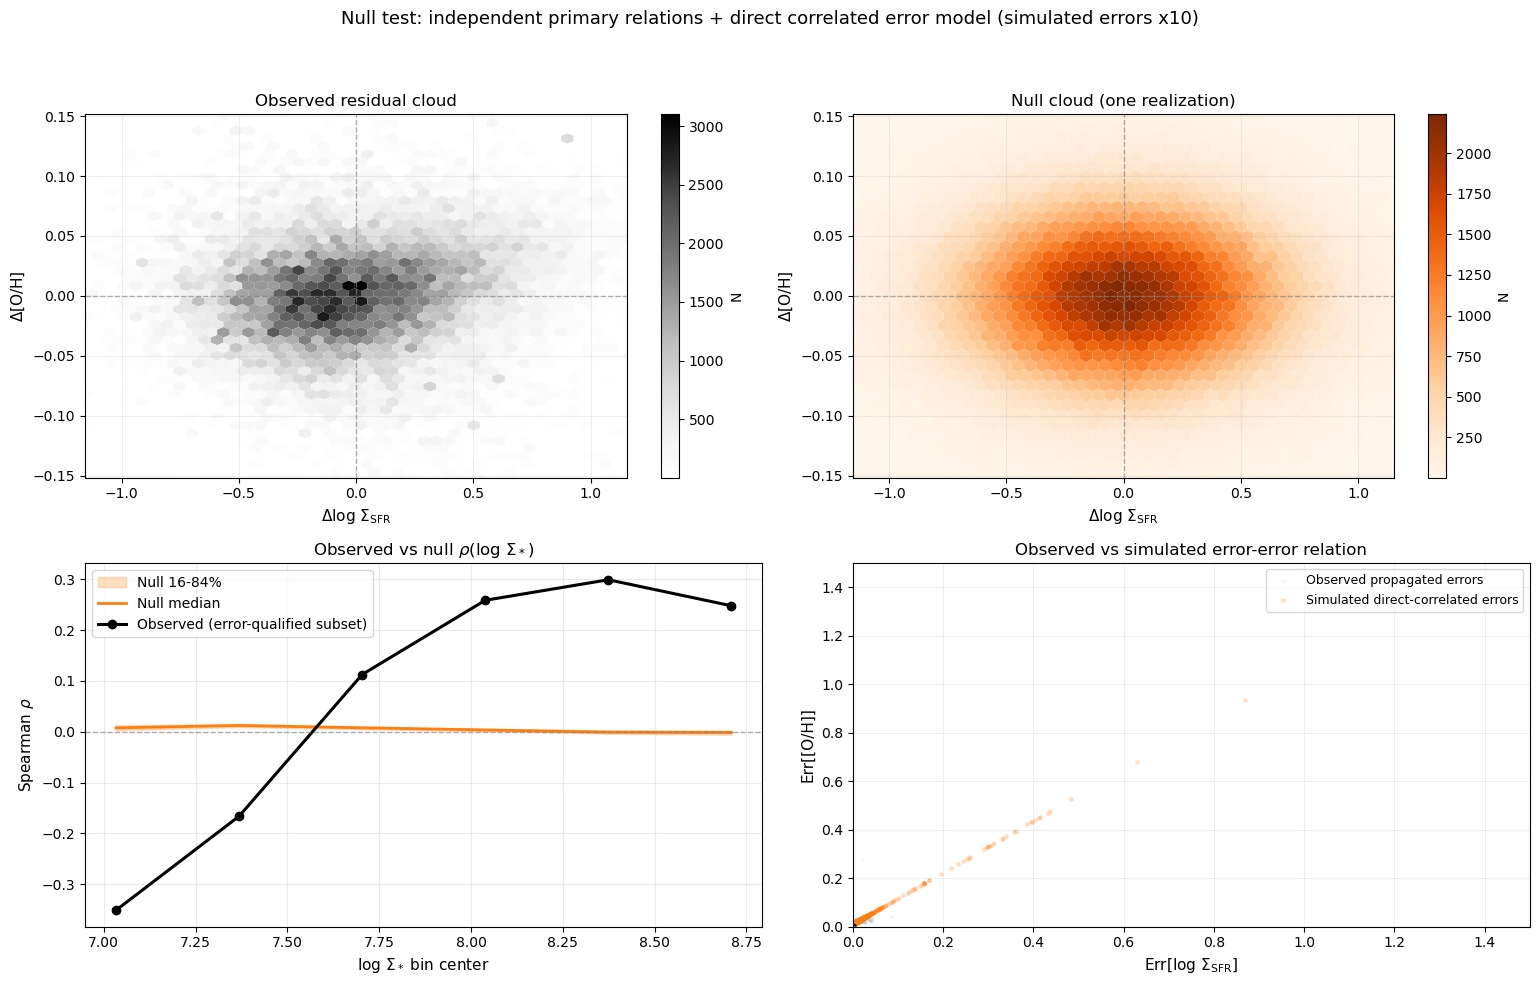

In [7]:
# ------------------------------------------------------------------
# Direct correlated error stress test: simulated errors x10
# ------------------------------------------------------------------
import numpy as np

from sec34_null_test_20260408 import (
    load_o3n2_m13_hii_sample_with_errors,
    make_percentile_mass_bin_edges,
    mask_sample,
    plot_sec34_style_null_test,
    print_sec34_summary,
    run_sec34_style_null_test,
)

required = ["global_sigM"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError("Run the global residual-analysis cell first. Missing variables: " + ", ".join(missing))

if "global_mass_bin_edges" not in globals():
    global_mass_bin_edges = make_percentile_mass_bin_edges(
        global_sigM,
        n_bins=6,
        lower_percentile=2.5,
        upper_percentile=97.5,
    )

if "sec34_sample" not in globals():
    sec34_full = load_o3n2_m13_hii_sample_with_errors(excluded_galaxies={"NGC4383"})
    finite_error_mask = np.isfinite(sec34_full["sigma_log_sfr"]) & np.isfinite(sec34_full["sigma_oh"])
    sec34_sample = mask_sample(sec34_full, finite_error_mask)

print("=" * 100)
print("Running direct correlated error stress test with simulated errors x10")
print("=" * 100)

sec34_result_x10 = run_sec34_style_null_test(
    sec34_sample,
    mass_bin_edges=global_mass_bin_edges,
    n_realizations=100,
    random_seed=726,
    error_scale=10.0,
    include_mass_error_proxy=True,
    mass_error_base=0.01,
)

print_sec34_summary(sec34_result_x10)
plot_sec34_style_null_test(sec34_result_x10)


### Direct Correlated Error Stress Test: `x100`

This cell reruns the same Sec. 3.4 null test, but multiplies the simulated direct-correlated errors by `100` before injecting them into the mock `log Sigma_SFR` and `[O/H]` values. Everything else in the null-test setup is kept the same.


Running direct correlated error stress test with simulated errors x100
Sec. 3.4-style null test summary
Bin       Mass range    center         N     obs rho    null p16    null med    null p84
  1    6.87-  7.20     7.034     55451     -0.3509     -0.0023      0.0023      0.0068
  2    7.20-  7.54     7.369     92955     -0.1660      0.0008      0.0040      0.0071
  3    7.54-  7.87     7.704    175453      0.1126     -0.0002      0.0023      0.0048
  4    7.87-  8.21     8.039    214572      0.2585     -0.0012      0.0010      0.0029
  5    8.21-  8.54     8.374    128656      0.2989     -0.0032     -0.0005      0.0023
  6    8.54-  8.88     8.709     76677      0.2478     -0.0043     -0.0006      0.0039
Direct correlated error fit: sigma([O/H]) = 0.001121 + 1.064187 * sigma(log Sigma_SFR)
Simulated error scale factor: x100


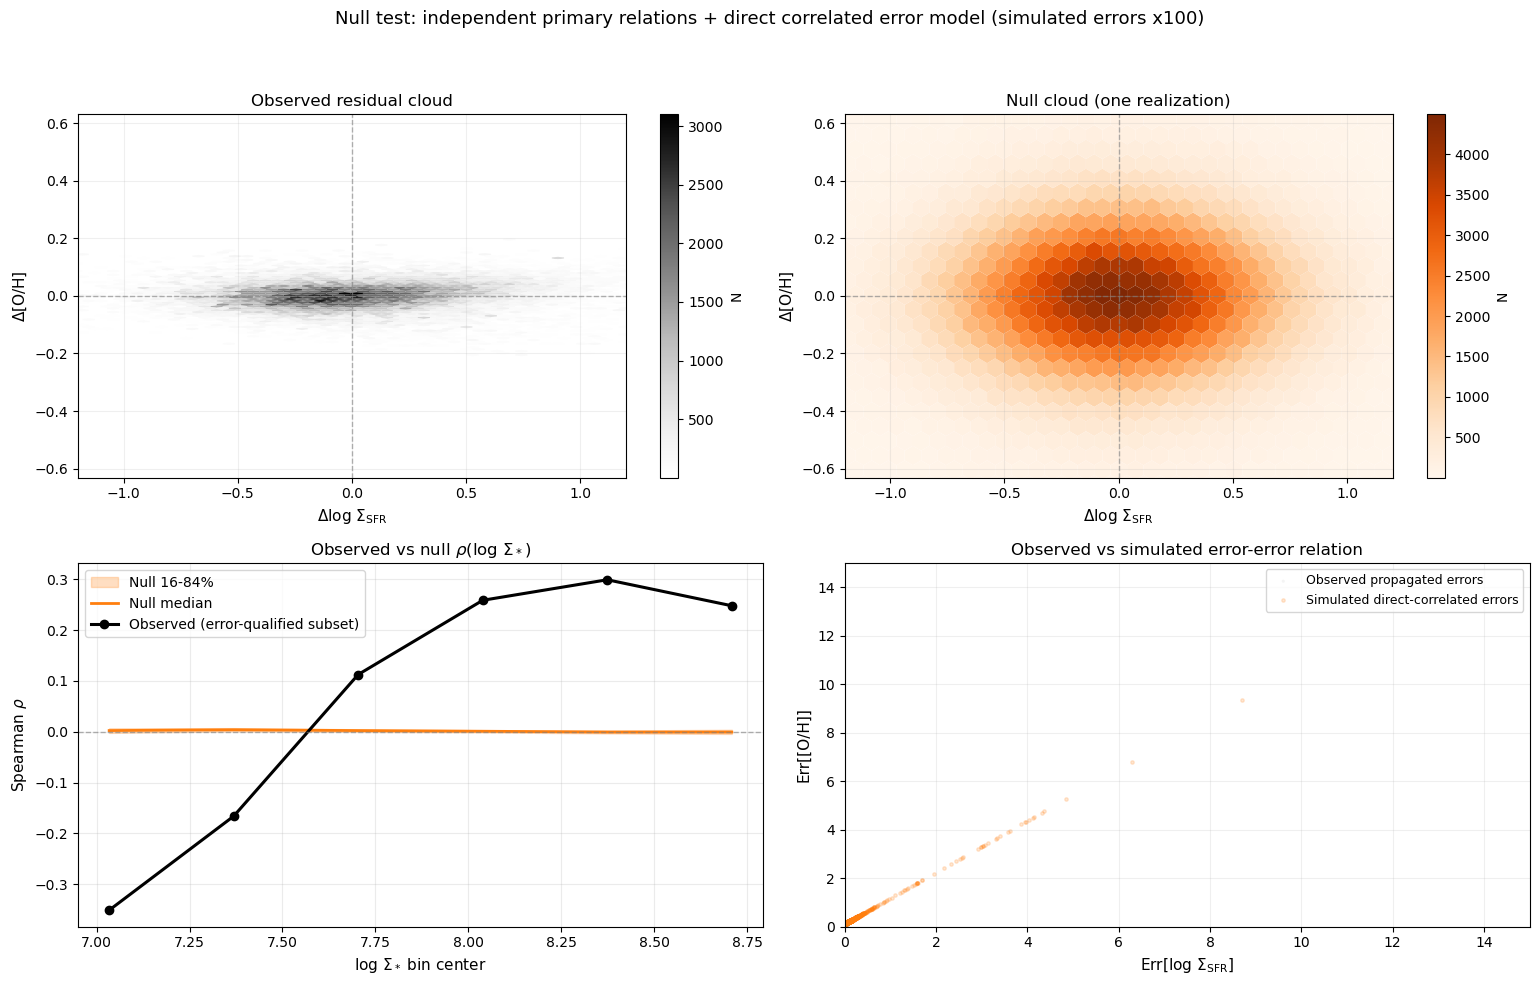

In [8]:
# ------------------------------------------------------------------
# Direct correlated error stress test: simulated errors x100
# ------------------------------------------------------------------
import numpy as np

from sec34_null_test_20260408 import (
    load_o3n2_m13_hii_sample_with_errors,
    make_percentile_mass_bin_edges,
    mask_sample,
    plot_sec34_style_null_test,
    print_sec34_summary,
    run_sec34_style_null_test,
)

required = ["global_sigM"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError("Run the global residual-analysis cell first. Missing variables: " + ", ".join(missing))

if "global_mass_bin_edges" not in globals():
    global_mass_bin_edges = make_percentile_mass_bin_edges(
        global_sigM,
        n_bins=6,
        lower_percentile=2.5,
        upper_percentile=97.5,
    )

if "sec34_sample" not in globals():
    sec34_full = load_o3n2_m13_hii_sample_with_errors(excluded_galaxies={"NGC4383"})
    finite_error_mask = np.isfinite(sec34_full["sigma_log_sfr"]) & np.isfinite(sec34_full["sigma_oh"])
    sec34_sample = mask_sample(sec34_full, finite_error_mask)

print("=" * 100)
print("Running direct correlated error stress test with simulated errors x100")
print("=" * 100)

sec34_result_x100 = run_sec34_style_null_test(
    sec34_sample,
    mass_bin_edges=global_mass_bin_edges,
    n_realizations=100,
    random_seed=726,
    error_scale=100.0,
    include_mass_error_proxy=True,
    mass_error_base=0.01,
)

print_sec34_summary(sec34_result_x100)
plot_sec34_style_null_test(sec34_result_x100)
